In [1]:
import pandas as pd
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt
import tifffile
import os

In [2]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=8, g=18, r=28):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    im = ax.imshow(img)  # 画像を表示
    plt.show()
    
#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

In [ ]:
mod_a0 = r"E:\permian_basin\data_1\bgn\normalized\bg_surref_0.00_scan.csv"
mod_a10 = r"E:\permian_basin\data_1\bgn\normalized\bg_surref_0.10_scan.csv"
band = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N318W1030_20221030160056_20231127193054\HSHL1G_N318W1030_20221030160056_20231127193054_B.csv"

bandinfo = pd.read_csv(band)
mod_a0 = pd.read_csv(mod_a0)
mod_a10 = pd.read_csv(mod_a10)

bandinfo_cols = bandinfo.columns.tolist()
mod_cols = mod_a0.columns.tolist()
print(bandinfo_cols, mod_cols)


['BandNo', 'CenterWavelengthNanometer', 'FullWidthAtHalfMaximumNanometer', 'SolarIrradianceWatt/Meter2/Micron', 'ReflectanceMulti', 'ReflectanceAdd', 'ReflectanceMaximum', 'ReflectanceMinimum', 'SceneMaximumDN', 'SceneMinimumDN', 'SceneAverageDN', 'SceneStandardDeviationDN', 'BadPixelCounts', 'InterpolatedBadPixelCounts', 'SaturatedPixelCounts'] ['wave_nm', 'radiance']


In [4]:
mod_a0_conv = mod_a0.copy()
mod_a10_conv = mod_a10.copy()
mod_a0_conv["radiance_wm2_sru_um"] = mod_a0_conv["radiance"] * 10
mod_a10_conv["radiance_wm2_sru_um"] = mod_a10_conv["radiance"] * 10 #単位
print(mod_a0_conv)
print(mod_a10_conv)

target_anchor_nm = 2139.0 #アルベド推定に2139nmを使用
bandinfo["abs_diff_anchor"] = (bandinfo["CenterWavelengthNanometer"] - target_anchor_nm).abs() #2139との差(絶対値)
anchor_row = bandinfo.loc[bandinfo["abs_diff_anchor"].idxmin()] #差が一番小さい列を取り出す
anchor_bandno = int(anchor_row["BandNo"])
anchor_center = float(anchor_row["CenterWavelengthNanometer"])
anchor_fwhm = float(anchor_row["FullWidthAtHalfMaximumNanometer"])
print(anchor_bandno, anchor_center, anchor_fwhm)

      wave_nm  radiance  radiance_wm2_sru_um
0      2100.0  0.004296             0.042965
1      2100.2  0.004250             0.042498
2      2100.4  0.004236             0.042356
3      2100.6  0.004254             0.042545
4      2100.8  0.004267             0.042669
...       ...       ...                  ...
1496   2399.2  0.002051             0.020507
1497   2399.4  0.002025             0.020247
1498   2399.6  0.001961             0.019612
1499   2399.8  0.001855             0.018554
1500   2400.0  0.001726             0.017263

[1501 rows x 3 columns]
      wave_nm  radiance  radiance_wm2_sru_um
0      2100.0  0.126179             1.261790
1      2100.2  0.123809             1.238090
2      2100.4  0.123096             1.230960
3      2100.6  0.124143             1.241430
4      2100.8  0.125014             1.250140
...       ...       ...                  ...
1496   2399.2  0.054125             0.541249
1497   2399.4  0.053423             0.534232
1498   2399.6  0.050961       

In [13]:
def gaussian_weights(wave_nm, center_nm, fwhm_nm):
    sigma = fwhm_nm / (2 * math.sqrt(2 * math.log(2)))  #FWHM -> sigma,半値点からx=μ±σ√2ln2これの差がFWHM
    w = np.exp(-0.5 * ((wave_nm - center_nm) / sigma) ** 2)
    w_sum = w.sum()
    if w_sum == 0:
        return w
    return w / w_sum

def convolve_band(wave_nm, rad, center_nm, fwhm_nm): #高分解能スペクトルrad(λ)を、そのバンドのRSR重みw(λ)で加重平均→そのバンドが実際に観測する放射輝度
    w = gaussian_weights(wave_nm, center_nm, fwhm_nm)
    return float(np.sum(rad * w))
wave_nm = mod_a0_conv["wave_nm"].values
rad_a0 = mod_a0_conv["radiance_wm2_sru_um"].values
rad_a10 = mod_a10_conv["radiance_wm2_sru_um"].values

L_path = convolve_band(wave_nm, rad_a0, anchor_center, anchor_fwhm) #反射0%でセンサが観測する明るさ
L10_anchor = convolve_band(wave_nm, rad_a10, anchor_center, anchor_fwhm)
print(wave_nm, rad_a0, rad_a10, L_path, L10_anchor)

[2100.  2100.2 2100.4 ... 2399.6 2399.8 2400. ] [0.042965  0.0424984 0.0423562 ... 0.0196121 0.0185539 0.0172634] [1.26179  1.23809  1.23096  ... 0.509614 0.466546 0.413773] 0.04265368153706776 1.3632435103013387


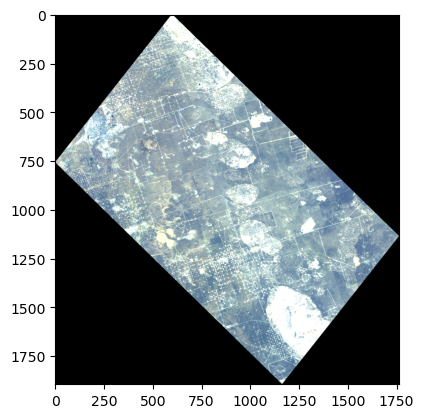

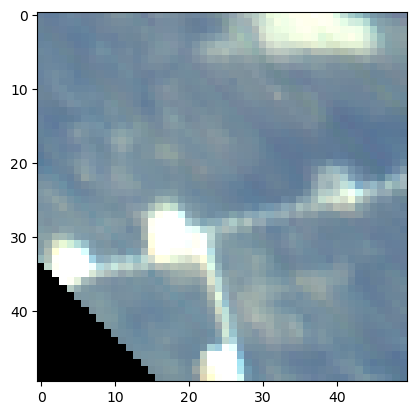

In [8]:
file = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N318W1030_20221030160056_20231127193054\HSHL1G_N318W1030_20221030160056_20231127193054.tif"
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1410, 700]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 25 : center[0] + 25, center[1] -25 : center[1] + 25, :] #補正後の画像
ims_slice = ims[center[0] - 25 : center[0] + 25, center[1] -25 : center[1] + 25, :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

In [9]:
cols = [
    "CenterWavelengthNanometer",
    "FullWidthAtHalfMaximumNanometer",
    "SolarIrradianceWatt/Meter2/Micron",
    "ReflectanceMulti",
    "ReflectanceAdd",
]

df_param = pd.DataFrame(param, columns=cols)  
print(df_param)

     CenterWavelengthNanometer  FullWidthAtHalfMaximumNanometer  \
0                      405.000                           9.9334   
1                      415.000                           9.9333   
2                      425.000                           9.9331   
3                      435.000                           9.9329   
4                      445.000                           9.9327   
..                         ...                              ...   
180                   2424.795                          13.1616   
181                   2437.285                          13.1601   
182                   2449.775                          13.1586   
183                   2462.265                          13.1570   
184                   2474.755                          13.1555   

     SolarIrradianceWatt/Meter2/Micron  ReflectanceMulti  ReflectanceAdd  
0                             1737.200          0.000018       -0.017834  
1                             1729.400       

In [10]:
ch4_df = df_param[(df_param["CenterWavelengthNanometer"] >= 2248.0) &
               (df_param["CenterWavelengthNanometer"] <= 2298.0)].copy()
ch4_df = ch4_df.sort_values("CenterWavelengthNanometer")

In [14]:
H, W, C = ims.shape
out_A  = np.full((H, W), np.nan, dtype=np.float32)
out_C  = np.full((H, W), np.nan, dtype=np.float32)
out_QA = np.zeros((H, W), dtype=np.uint8)
anchor_target = 2139
df_param = df_param.copy()
df_param["absdiff"] = (df_param["CenterWavelengthNanometer"] - anchor_target).abs()
anchor_row = df_param.loc[df_param["absdiff"].idxmin()]

ANCHOR_CENTER = float(anchor_row["CenterWavelengthNanometer"])
ANCHOR_FWHM   = float(anchor_row["FullWidthAtHalfMaximumNanometer"])

CH4_BANDS = ch4_df[["CenterWavelengthNanometer","FullWidthAtHalfMaximumNanometer"]].to_numpy()

Lb_list = []
for center_nm, fwhm_nm in CH4_BANDS:
    Lb_list.append(
        convolve_band(wave_nm, rad_a10, float(center_nm), float(fwhm_nm))
    )
Lb_list = np.array(Lb_list, dtype=float)
N_CH4 = len(CH4_BANDS)  

for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

        pix_wave = df["Wavelength"].to_numpy(dtype=float)
        pix_rad  = df["Radiance"].to_numpy(dtype=float)  

        idx_anchor  = int(np.abs(pix_wave - ANCHOR_CENTER).argmin())
        Lav_anchor  = float(pix_rad[idx_anchor])

        denom = (L10_anchor - L_path)
        if not np.isfinite(Lav_anchor) or denom <= 0:
            out_QA[y, x] = 1
            continue
        A = (Lav_anchor - L_path) / denom * 0.10
        if not np.isfinite(A) or A <= 0:
            out_QA[y, x] = 1
            continue

        chi = 0.10 / A

        sum_res = 0.0
        for j, (center_nm, fwhm_nm) in enumerate(CH4_BANDS):
            idx  = int(np.abs(pix_wave - center_nm).argmin())
            Lav  = float(pix_rad[idx])
            Lb   = float(Lb_list[j])
            Lres = Lb - chi * Lav
            sum_res += Lres

        C_scaled = (sum_res / (N_CH4 * A)) * 100.0

        out_A[y, x] = A
        out_C[y, x] = C_scaled

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

CH4(ppm) stats on valid pixels: -8.927319 7.9425144 6447152.0


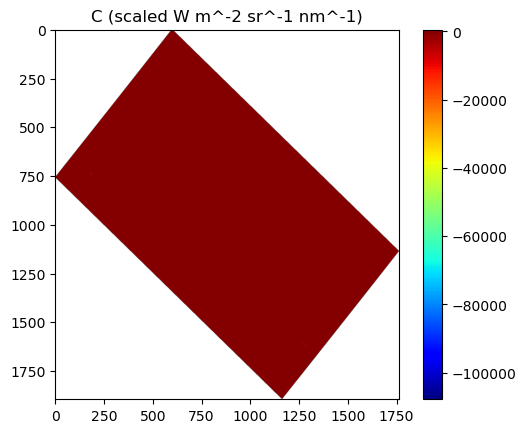

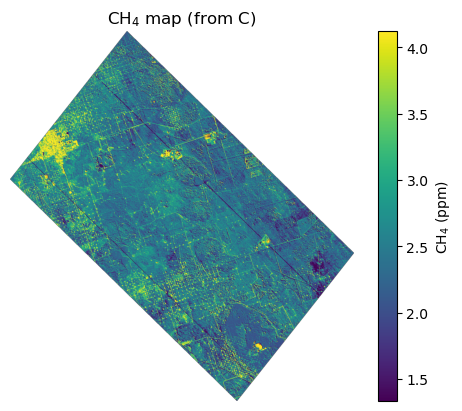

In [15]:
plt.imshow(out_C, cmap="jet"); plt.colorbar(); plt.title("C (scaled W m^-2 sr^-1 nm^-1)")
def c_to_ch4_ppm(C):
    return 0.000556 * (C**2) + 0.1519 * C + 1.4475

valid = np.isfinite(out_C)
if 'out_QA' in globals():
    valid &= (out_QA == 0)

CH4_ppm = np.full_like(out_C, np.nan, dtype=np.float32)
CH4_ppm[valid] = c_to_ch4_ppm(out_C[valid])

print("CH4(ppm) stats on valid pixels:",
      np.nanmin(CH4_ppm), np.nanmean(CH4_ppm), np.nanmax(CH4_ppm))

plt.figure()
plt.imshow(CH4_ppm, vmin=np.nanpercentile(CH4_ppm, 2), vmax=np.nanpercentile(CH4_ppm, 98))
plt.colorbar(label="CH$_4$ (ppm)")
plt.title("CH$_4$ map (from C)")
plt.axis("off")
plt.show()



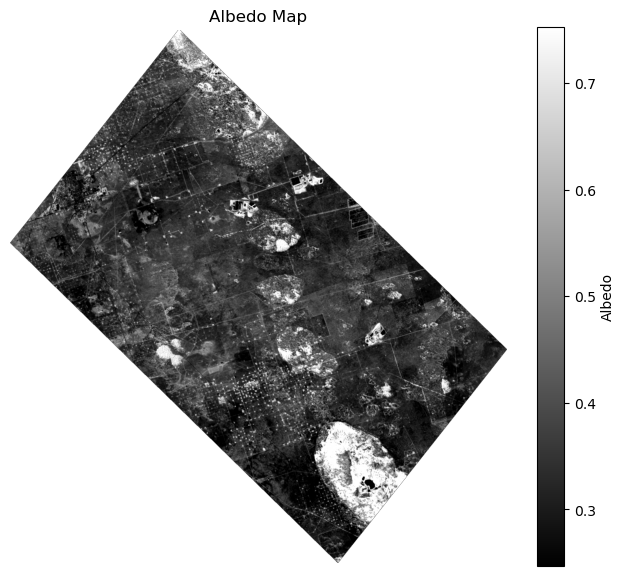

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# out_A が計算済みであることを前提としています

# グラフの表示設定
plt.figure(figsize=(8, 7))

# 外れ値の影響を抑えて見やすくするため、カラーマップの最小・最大値を2パーセンタイルと98パーセンタイルに設定
vmin_val = np.nanpercentile(out_A, 2)
vmax_val = np.nanpercentile(out_A, 98)

# out_A をグレースケールで画像として表示
plt.imshow(out_A, cmap='gray', vmin=vmin_val, vmax=vmax_val)

# カラーバーとタイトルを追加
plt.colorbar(label="Albedo")
plt.title("Albedo Map")

# 軸を非表示にする
plt.axis('off')

# 画像を表示
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import sobel, laplace

# Matplotlibの日本語設定（環境に応じてフォント名を変更してください）
plt.rcParams['font.family'] = 'Meiryo'

In [18]:
def apply_filter(image, filter_type='sobel'):
    """
    画像に指定されたフィルタを適用し、勾配（エッジ）を計算する関数。

    Args:
        image (np.array): 入力画像（2次元配列）。
        filter_type (str): 'sobel' または 'laplacian' を指定。

    Returns:
        np.array: 勾配（エッジ）が強調された画像。
    """
    # 0や負の値があるとフィルタの挙動が意図しない場合があるため、0以上の値にクリップ
    image = np.clip(image, 0, None)
    
    if filter_type.lower() == 'sobel':
        # X方向とY方向の勾配を計算
        dx = sobel(image, axis=0)  # Y方向の変化
        dy = sobel(image, axis=1)  # X方向の変化
        # 勾配の大きさを計算（ピタゴラスの定理）
        gradient = np.hypot(dx, dy)
        return gradient
    
    elif filter_type.lower() == 'laplacian':
        # ラプラシアンフィルタを適用
        return np.abs(laplace(image))
    
    else:
        raise ValueError("対応していないフィルタです。'sobel' または 'laplacian' を選択してください。")

In [22]:
# --- ▼▼▼ ユーザー設定 ▼▼▼ ---
# 使用するフィルタを選択 ('sobel' または 'laplacian')
selected_filter = 'sobel'
# --- ▲▲▲ ユーザー設定ここまで ▲▲▲ ---

# 1. 各マップに選択したフィルタを適用して勾配を計算
albedo_gradient = apply_filter(out_A, filter_type=selected_filter)
ch4_gradient = apply_filter(CH4_ppm, filter_type=selected_filter)

# 2. 勾配マップを正規化（0-1の範囲にスケーリング）して比較しやすくする
# 最大値が0の場合のエラーを回避
albedo_grad_max = albedo_gradient.max()
ch4_grad_max = ch4_gradient.max()

norm_albedo_gradient = albedo_gradient / albedo_grad_max if albedo_grad_max > 0 else albedo_gradient
norm_ch4_gradient = ch4_gradient / ch4_grad_max if ch4_grad_max > 0 else ch4_gradient

# 3. 正規化後の勾配マップの差分（絶対値）を計算
diff_map = np.abs(norm_ch4_gradient - norm_albedo_gradient)

# 4. 差分マップの上位5%に相当する閾値を計算
# データがないピクセル（差が0）を除外してパーセンタイルを計算
valid_diff_values = diff_map[diff_map > 0]
if len(valid_diff_values) > 0:
    threshold = np.percentile(valid_diff_values, 95)  # 上位5% -> 95パーセンタイル
else:
    threshold = diff_map.max() + 1 # 有効な差分がない場合は、何も選択されないようにする

# 5. 閾値を超えるピクセルを「メタン異常」として抽出（True/Falseのマスク画像）
anomaly_mask = diff_map > threshold

print(f"選択したフィルタ: {selected_filter}")
print(f"差分の上位5%の閾値: {threshold:.4f}")
print(f"検出された異常ピクセル数: {np.sum(anomaly_mask)} ピクセル")

選択したフィルタ: sobel
差分の上位5%の閾値: 6.0017
検出された異常ピクセル数: 77774 ピクセル


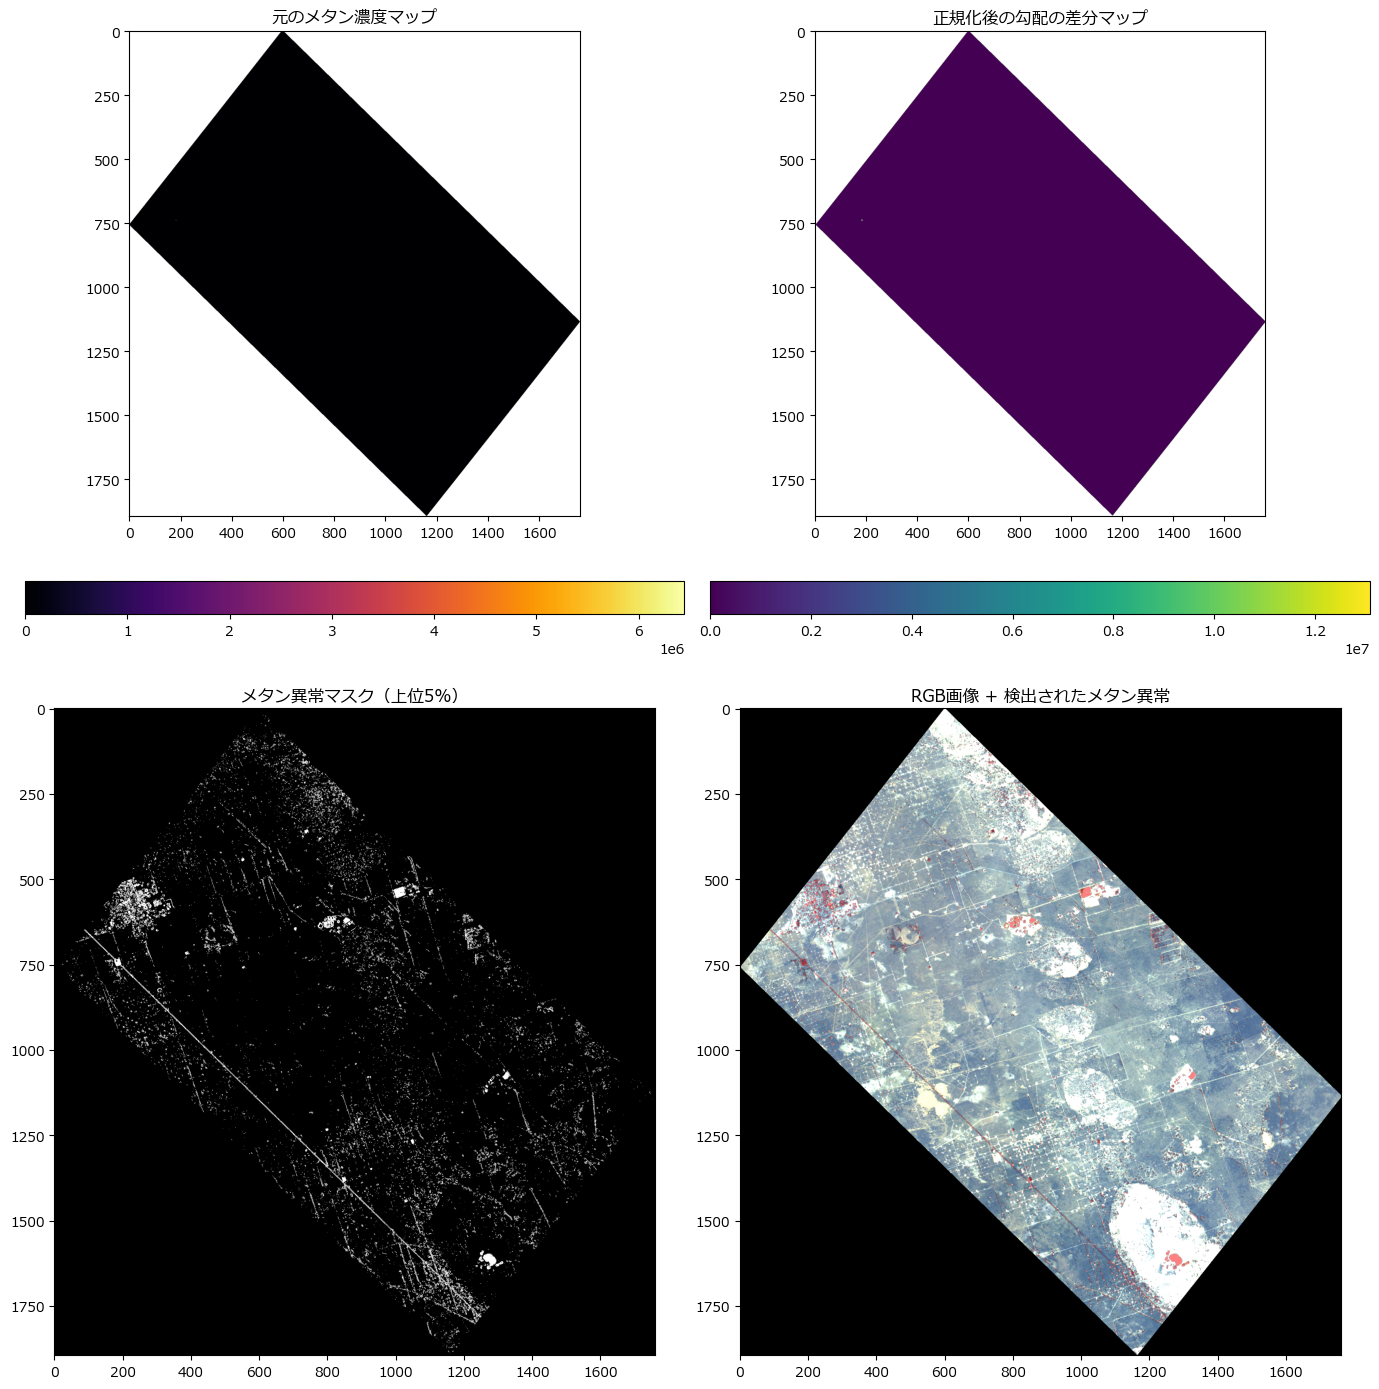

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# 元のメタンマップ
im1 = axes[0, 0].imshow(CH4_ppm, cmap='inferno')
axes[0, 0].set_title('元のメタン濃度マップ')
fig.colorbar(im1, ax=axes[0, 0], orientation='horizontal', pad=0.1)

# 勾配の差分マップ
im2 = axes[0, 1].imshow(diff_map, cmap='viridis')
axes[0, 1].set_title('正規化後の勾配の差分マップ')
fig.colorbar(im2, ax=axes[0, 1], orientation='horizontal', pad=0.1)

# 抽出された異常マスク
axes[1, 0].imshow(anomaly_mask, cmap='gray')
axes[1, 0].set_title('メタン異常マスク（上位5%）')

# 元画像に異常箇所を重ねて表示
# 表示用のRGB画像(ims_slice)の上に、半透明の赤色でマスクを重ねる
axes[1, 1].imshow(ims)
# RGBA形式で色（赤）と不透明度（alpha=0.5）を指定
red_overlay = np.zeros((*anomaly_mask.shape, 4))
red_overlay[anomaly_mask] = [1, 0, 0, 0.5]  # Trueの箇所を半透明の赤色に
axes[1, 1].imshow(red_overlay)
axes[1, 1].set_title('RGB画像 + 検出されたメタン異常')

# レイアウトを調整
plt.tight_layout()
plt.show()

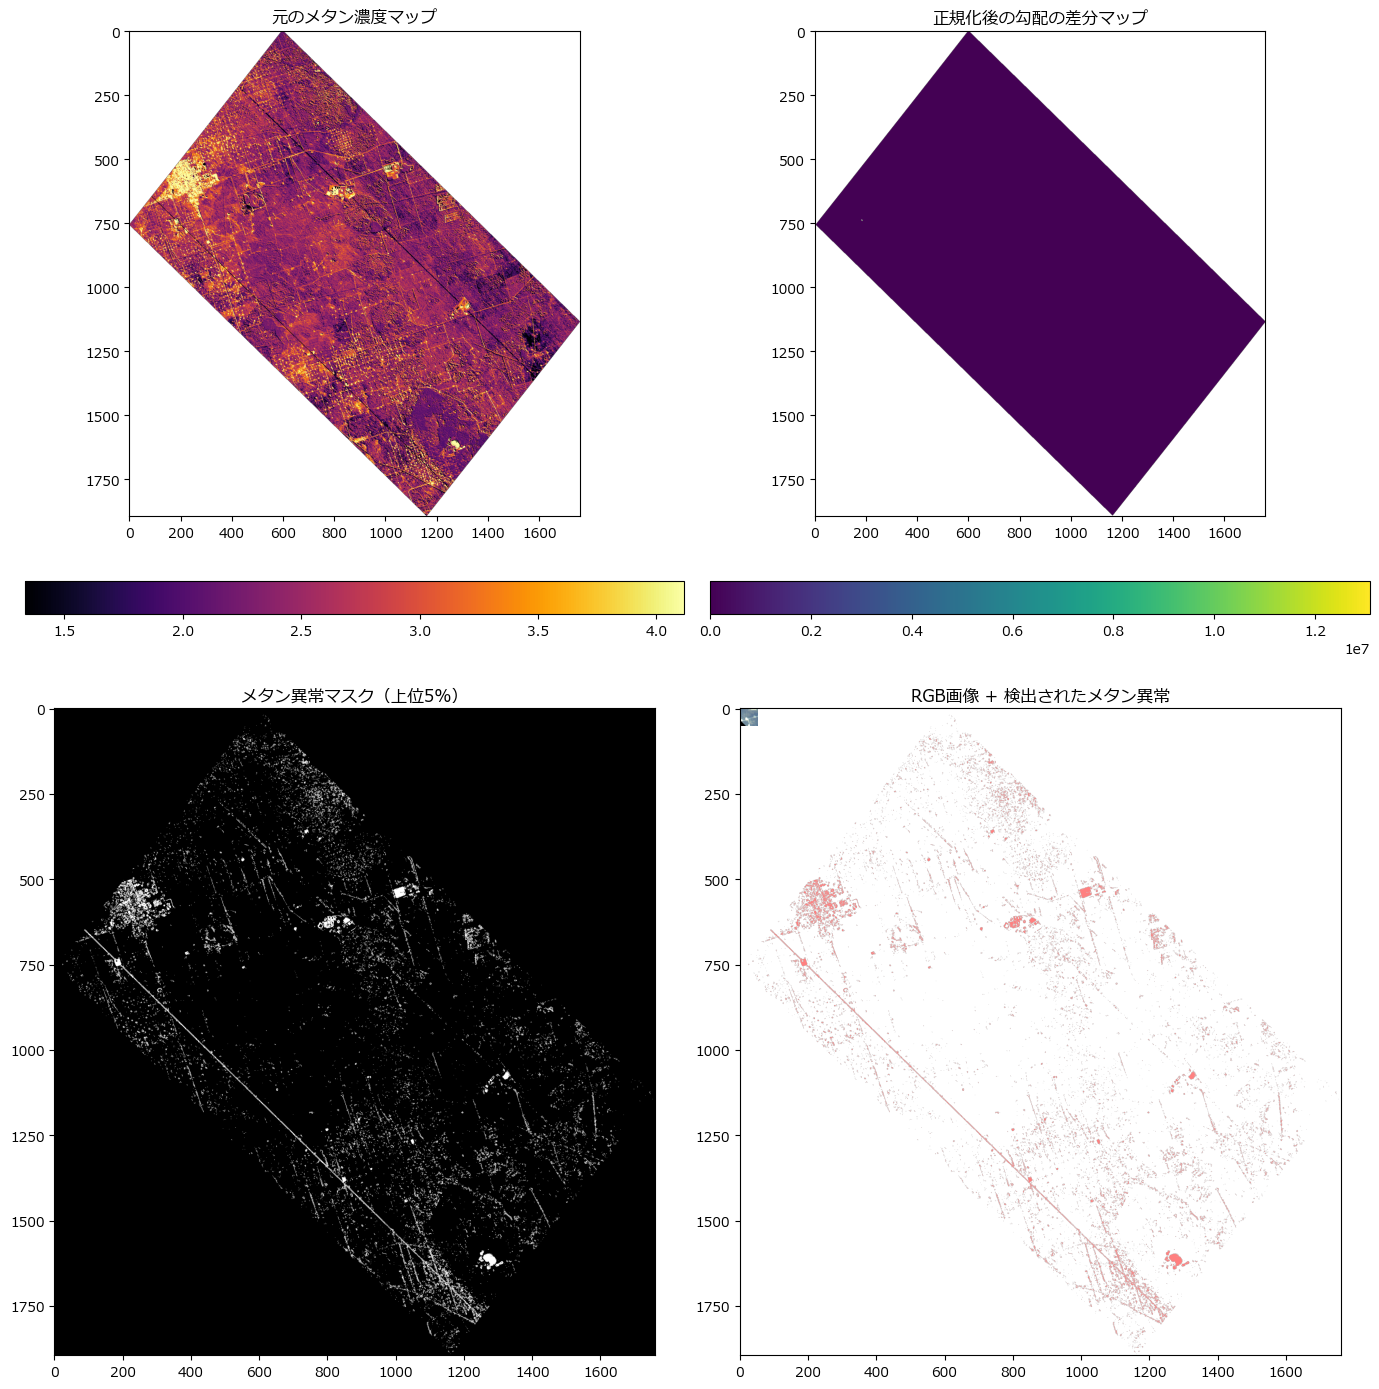

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# --- ▼▼▼ ここを修正 ▼▼▼ ---
# 元のメタンマップ
# 外れ値の影響を抑えるため、カラーマップの範囲を2~98パーセンタイルに設定
# NaN値を無視してパーセンタイルを計算します
ch4_min = np.nanpercentile(CH4_ppm, 2)
ch4_max = np.nanpercentile(CH4_ppm, 98)
im1 = axes[0, 0].imshow(CH4_ppm, cmap='inferno', vmin=ch4_min, vmax=ch4_max)
# --- ▲▲▲ 修正ここまで ▲▲▲ ---

axes[0, 0].set_title('元のメタン濃度マップ')
fig.colorbar(im1, ax=axes[0, 0], orientation='horizontal', pad=0.1)

# 勾配の差分マップ
im2 = axes[0, 1].imshow(diff_map, cmap='viridis')
axes[0, 1].set_title('正規化後の勾配の差分マップ')
fig.colorbar(im2, ax=axes[0, 1], orientation='horizontal', pad=0.1)

# 抽出された異常マスク
axes[1, 0].imshow(anomaly_mask, cmap='gray')
axes[1, 0].set_title('メタン異常マスク（上位5%）')

# 元画像に異常箇所を重ねて表示
# 【修正案】切り出した範囲のRGB画像(ims_slice)に重ねる方が、範囲が合致します
axes[1, 1].imshow(ims_slice) 
# RGBA形式で色（赤）と不透明度（alpha=0.5）を指定
red_overlay = np.zeros((*anomaly_mask.shape, 4))
red_overlay[anomaly_mask] = [1, 0, 0, 0.5]  # Trueの箇所を半透明の赤色に
axes[1, 1].imshow(red_overlay)
axes[1, 1].set_title('RGB画像 + 検出されたメタン異常')

# レイアウトを調整
plt.tight_layout()
plt.show()